In [6]:
from pathlib import Path
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from loguru import logger

datadir = Path.home() / ".cache" / "mads_datasets"
datadir.mkdir(parents=True, exist_ok=True)
logger.info(f"Data directory: {datadir}")

transform = transforms.ToTensor()

train_data = datasets.SVHN(root=datadir, split='train', download=True, transform=transform)
test_data = datasets.SVHN(root=datadir, split='test', download=True, transform=transform)

logger.info(f"Train size: {len(train_data)}")
logger.info(f"Test size: {len(test_data)}")

2026-03-13 19:46:46.087 | INFO     | __main__:<module>:12 - Data directory: /Users/stevenbontius/.cache/mads_datasets
2026-03-13 19:46:47.536 | INFO     | __main__:<module>:19 - Train size: 73257
2026-03-13 19:46:47.536 | INFO     | __main__:<module>:20 - Test size: 26032


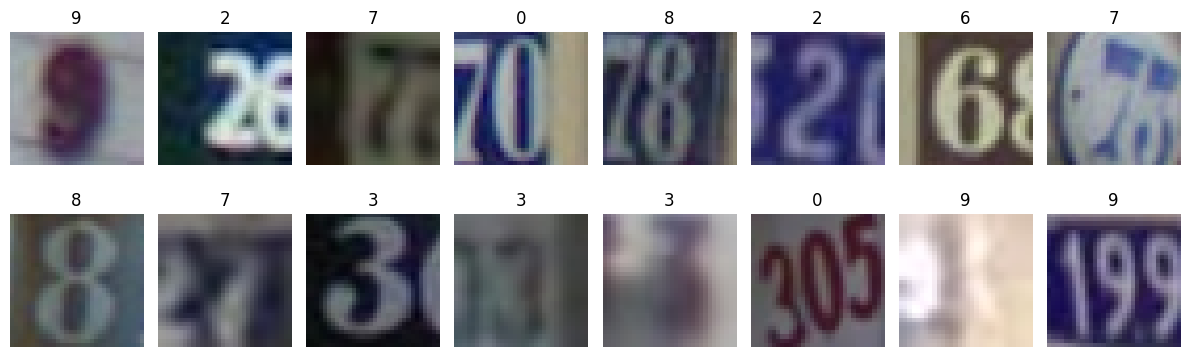

In [9]:
loader = DataLoader(train_data, batch_size=16, shuffle=True)
images, labels = next(iter(loader))

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(labels[i].item())
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
labels = np.array(train_data.labels)
classes, counts = np.unique(labels, return_counts=True)

for c, count in zip(classes, counts):
    logger.info(f"Class {c}: {count} samples ({count/len(labels)*100:.1f}%)")

2026-03-13 19:46:55.985 | INFO     | __main__:<module>:5 - Class 0: 4948 samples (6.8%)
2026-03-13 19:46:55.986 | INFO     | __main__:<module>:5 - Class 1: 13861 samples (18.9%)
2026-03-13 19:46:55.987 | INFO     | __main__:<module>:5 - Class 2: 10585 samples (14.4%)
2026-03-13 19:46:55.987 | INFO     | __main__:<module>:5 - Class 3: 8497 samples (11.6%)
2026-03-13 19:46:55.987 | INFO     | __main__:<module>:5 - Class 4: 7458 samples (10.2%)
2026-03-13 19:46:55.988 | INFO     | __main__:<module>:5 - Class 5: 6882 samples (9.4%)
2026-03-13 19:46:55.988 | INFO     | __main__:<module>:5 - Class 6: 5727 samples (7.8%)
2026-03-13 19:46:55.988 | INFO     | __main__:<module>:5 - Class 7: 5595 samples (7.6%)
2026-03-13 19:46:55.989 | INFO     | __main__:<module>:5 - Class 8: 5045 samples (6.9%)
2026-03-13 19:46:55.989 | INFO     | __main__:<module>:5 - Class 9: 4659 samples (6.4%)


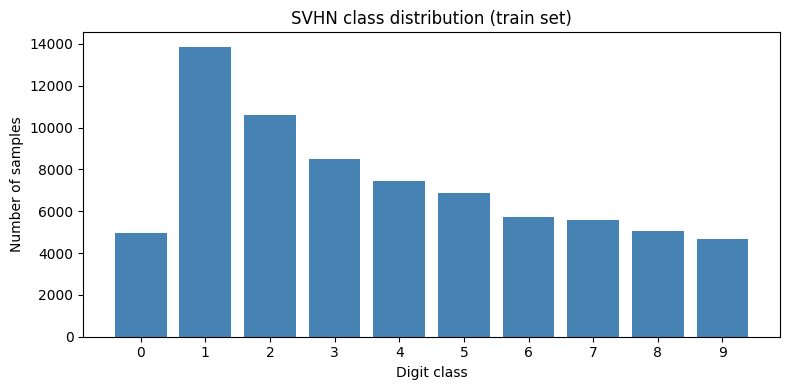

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, counts, color='steelblue')
ax.set_xlabel('Digit class')
ax.set_ylabel('Number of samples')
ax.set_title('SVHN class distribution (train set)')
ax.set_xticks(classes)
plt.tight_layout()
plt.show()

In [ ]:
# calculate mean and std per channel
imgs = torch.stack([img for img, _ in train_data])
mean = imgs.mean(dim=[0, 2, 3])
std = imgs.std(dim=[0, 2, 3])
logger.info(f"Mean: {mean}")
logger.info(f"Std: {std}")

2026-03-13 20:22:28.619 | INFO     | __main__:<module>:5 - Mean: tensor([0.4377, 0.4438, 0.4728])
2026-03-13 20:22:28.621 | INFO     | __main__:<module>:6 - Std: tensor([0.1980, 0.2010, 0.1970])
